# 06 · Tournament Simulation
Phase 6: Monte Carlo simulation with N=50,000 iterations.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib
from pathlib import Path
from src.data_loader import load_all
from src.dixon_coles import DixonColes
from src.elo_calculator import build_elo_ratings
from src.tournament_simulator import TournamentSimulator, compute_penalty_probability
np.random.seed(42)

data = load_all(verbose=False)
fixtures    = data['group_fixtures']
ko_slots    = data['knockout_slots']
shootouts   = data['shootouts']
results_full = data['results_full']

# Load or rebuild Elo
elo_path = Path('../data/processed/team_elo_ratings.csv')
if elo_path.exists():
    elo_df = pd.read_csv(elo_path)
    elo_ratings = dict(zip(elo_df['team'], elo_df['elo_rating']))
    print(f"Loaded Elo ratings: {len(elo_ratings)} teams")
else:
    _, elo_ratings = build_elo_ratings(results_full, save=True)


INFO | Loading results from /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/raw/results.csv


INFO |   Raw rows: 49,477


WARNING |   Found 2 duplicate match entries — dropping


INFO |   Full dataset: 49,475 rows | Primary (1990+): 32,358


INFO | former_names.csv columns: ['current', 'former', 'start_date', 'end_date']


...

INFO | Loaded knockout slots: 32 matches


INFO | Loaded FIFA rankings for 48 teams


INFO | Loaded WC historical stats: 964 matches (1930-2022)


INFO | Saved team_registry.csv: 48 teams → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/team_registry.csv


Loaded Elo ratings: 335 teams


## 6.1 Load Dixon-Coles Model

In [2]:
import json
params_path = Path('../outputs/model_artifacts/dixon_coles_params.json')
if params_path.exists():
    with open(params_path) as f:
        dc_params = json.load(f)
    # Re-fit the model (must re-fit since we can't easily serialize the numpy arrays)
    print("Refitting Dixon-Coles for simulation...")
else:
    print("No saved params. Fitting Dixon-Coles now...")

train_final = results_full[results_full['date'].dt.year >= 2015].copy()
dc_model = DixonColes(xi=0.003)
dc_model.fit(train_final)
print(f"Dixon-Coles ready. Teams: {len(dc_model.teams_)}, rho={dc_model._rho:.4f}")


INFO | Fitting Dixon-Coles on 11,038 matches, 295 teams


INFO |   Running L-BFGS-B optimisation...


Refitting Dixon-Coles for simulation...


WARNING |   Optimisation did not fully converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT


INFO |   home_adv=0.2264, rho=-0.1247


Dixon-Coles ready. Teams: 295, rho=-0.1247


## 6.2 Run Monte Carlo Simulation (N=50,000)

In [3]:
%%time
N = 50_000
print(f"Starting Monte Carlo simulation: {N:,} iterations")
print("Estimated time: 5-15 minutes depending on hardware")
print("-" * 50)

simulator = TournamentSimulator(
    dc_model=dc_model,
    group_fixtures=fixtures,
    knockout_slots=ko_slots,
    elo_ratings=elo_ratings,
    shootout_df=shootouts,
    seed=42
)

results_sim = simulator.run(n_simulations=N, n_jobs=1)
simulator.save_results(results_sim)
print("\n✅ Simulation complete!")


INFO | Simulator initialised. Groups: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'], Penalty rate: 1.00


INFO | Starting 50,000 simulations across 1 cores...


Starting Monte Carlo simulation: 50,000 iterations
Estimated time: 5-15 minutes depending on hardware
--------------------------------------------------


  ✅ All 50,000 simulations complete!


INFO | Saved tournament_winner_probs → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/tournament_winner_probs.csv


INFO | Saved knockout_team_probabilities → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/knockout_team_probabilities.csv


INFO | Saved knockout_predictions → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/knockout_predictions.csv


INFO | Saved group_stage_probabilities → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/group_stage_probabilities.csv



✅ Simulation complete!
CPU times: user 5min, sys: 4.9 s, total: 5min 5s
Wall time: 14min 47s


## 6.3 Tournament Winner Probabilities

🏆 TOP 15 TOURNAMENT WINNER PROBABILITIES
  Argentina            26.8%  █████████████████████████████████████████████████████
  Japan                10.2%  ████████████████████
  Spain                7.1%  ██████████████
  Brazil               6.0%  ███████████
  Portugal             4.3%  ████████
  Morocco              4.2%  ████████
  Colombia             4.2%  ████████
  Mexico               3.8%  ███████
  France               3.7%  ███████
  Switzerland          3.3%  ██████
  Germany              3.0%  ██████
  Ecuador              3.0%  ██████
  England              3.0%  ██████
  Belgium              2.0%  ███
  Netherlands          1.9%  ███


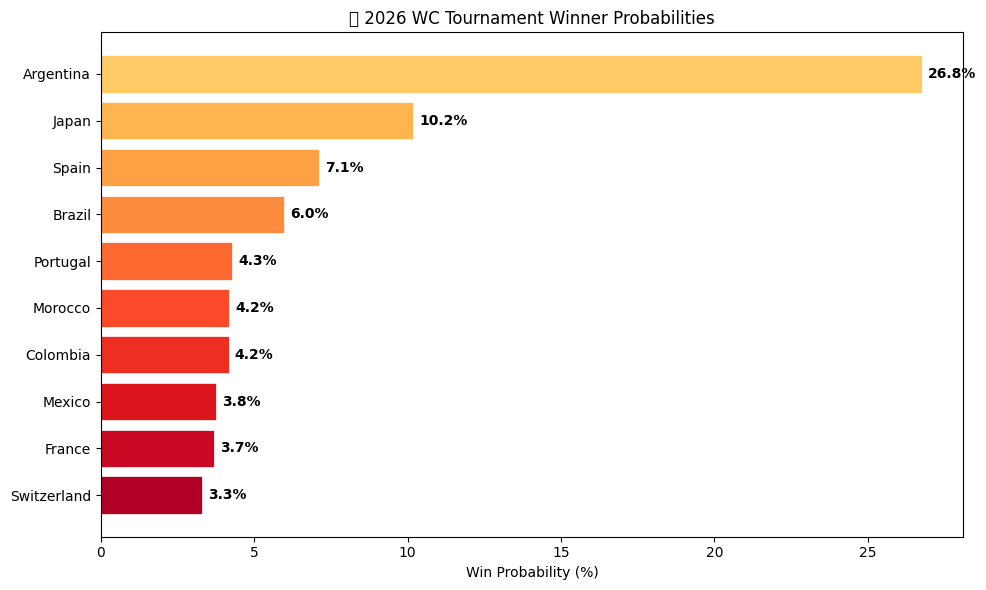

In [4]:
winner_probs = results_sim['winner_probs']
print("🏆 TOP 15 TOURNAMENT WINNER PROBABILITIES")
print("=" * 55)
for _, row in winner_probs.head(15).iterrows():
    bar = '█' * int(row['win_probability'] * 200)
    print(f"  {row['team']:<20} {row['win_probability']:.1%}  {bar}")

plt.figure(figsize=(10, 6))
top10 = winner_probs.head(10)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top10)))[::-1]
bars = plt.barh(top10['team'][::-1], top10['win_probability'][::-1]*100,
                color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top10['win_probability'][::-1]*100):
    plt.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')
plt.xlabel('Win Probability (%)'); plt.title('🏆 2026 WC Tournament Winner Probabilities')
plt.tight_layout()
plt.savefig('../outputs/plots/tournament_winner_probs.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.4 Group Stage Qualification Probabilities

In [5]:
group_probs = results_sim['group_probs']
print("GROUP STAGE QUALIFICATION PROBABILITIES")
print("=" * 60)
for g in 'ABCDEFGHIJKL':
    group = group_probs[group_probs['group'] == g].sort_values('p_1st', ascending=False)
    print(f"\nGroup {g}:")
    print(f"  {'Team':<22} {'P(1st)':<10} {'P(2nd)':<10} {'P(Advance)'}")
    for _, r in group.iterrows():
        print(f"  {r['team']:<22} {r['p_1st']:.1%}      {r['p_2nd']:.1%}      {r['p_advance']:.1%}")


GROUP STAGE QUALIFICATION PROBABILITIES

Group A:
  Team                   P(1st)     P(2nd)     P(Advance)
  Mexico                 59.3%      25.5%      84.8%
  South Korea            22.2%      34.6%      56.8%
  Czechia                13.3%      25.1%      38.3%
  South Africa           5.2%      14.8%      20.0%

Group B:
  Team                   P(1st)     P(2nd)     P(Advance)
  Switzerland            60.4%      31.3%      91.7%
  Canada                 34.3%      49.1%      83.4%
  Bosnia and Herzegovina 5.1%      17.6%      22.7%
  Qatar                  0.3%      1.9%      2.2%

Group C:
  Team                   P(1st)     P(2nd)     P(Advance)
  Brazil                 54.1%      28.1%      82.2%
  Morocco                29.8%      39.7%      69.5%
  Scotland               14.5%      26.3%      40.8%
  Haiti                  1.5%      5.9%      7.4%

Group D:
  Team                   P(1st)     P(2nd)     P(Advance)
  Paraguay               28.4%      26.1%      54.5%
  USA  

## 6.5 Knockout Bracket Predictions

In [6]:
ko_preds = results_sim['ko_predictions']
print("KNOCKOUT STAGE PREDICTIONS (Most Likely Matchups)")
for rnd in ['Round of 32','Round of 16','Quarter-final','Semi-final','Final']:
    rnd_preds = ko_preds[ko_preds['round'] == rnd]
    print(f"\n{'─'*50}")
    print(f"  {rnd.upper()}")
    print(f"{'─'*50}")
    for _, r in rnd_preds.iterrows():
        winner = r.get('predicted_winner', '?')
        print(f"  {r['predicted_home']:<20} vs {r['predicted_away']:<20}  → {winner}")


KNOCKOUT STAGE PREDICTIONS (Most Likely Matchups)

──────────────────────────────────────────────────
  ROUND OF 32
──────────────────────────────────────────────────
  Mexico               vs Canada                → Mexico
  Switzerland          vs South Korea           → Switzerland
  Brazil               vs Morocco               → Brazil
  Morocco              vs Paraguay              → Morocco
  Netherlands          vs Germany               → Germany
  Japan                vs Ecuador               → Japan
  Belgium              vs Uruguay               → Belgium
  Spain                vs Iran                  → Spain
  France               vs Austria               → France
  Argentina            vs Norway                → Argentina
  Colombia             vs Portugal              → Colombia
  England              vs Portugal              → England
  Côte d'Ivoire        vs Bosnia and Herzegovina  → Côte d'Ivoire
  Bosnia and Herzegovina vs Austria               → Austria
  Sweden   

## ✅ Phase 6 Complete
- 50,000 simulations run
- Group probabilities, knockout predictions, winner probabilities saved
- All outputs in `data/processed/` and `outputs/predictions/`